In [10]:
import pandas as pd
import os.path as op
import numpy as np
from os import listdir
import pingouin
import matplotlib.pyplot as plt
import seaborn as sns

bids_folder = '/Volumes/mrenkeED/data/ds-stressrisk'
bids_folder_behav ='/Users/mrenke/data/ds-stressrisk'
subFolders = [f for f in listdir(bids_folder) if f[0:3] == 'sub']

In [4]:
from stress_risk.utils.data import get_data

df = get_data(bids_folder = bids_folder, value=True)
#df.to_csv('/Users/mrenke/data/ds-stressrisk/interim_sum_data/all_behavior_df.csv')
group_mapping = df.groupby(['subject', 'group']).size().reset_index(['group']).drop(0, axis=1)


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package outdated is out of date. Your version is 0.2.1, the latest is 0.2.2.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.2, the latest is 0.5.3.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [5]:
from tqdm.contrib.itertools import product
from utils import get_decoding_info

subjects = df.reset_index()['subject'].unique()
sessions = [1, 2]
n_voxels = 'select'

pred = []
for (sub, session) in product(subjects, sessions):
    pred.append(get_decoding_info(sub, session,bids_folder=bids_folder, mask ='mpfc', n_voxels=n_voxels, retroicor=False,value=True))

pred = pd.concat(pred)
pred = pred.join(df['log(n1)'], how='inner')
pred = pred.reset_index(['mask','n_voxels','run']).drop(['mask','n_voxels','run'], axis=1) #remove unneccessary indices

  0%|          | 0/100 [00:00<?, ?it/s]

 12%|█▏        | 12/100 [00:00<00:02, 35.80it/s]

/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.cv_voxel_selection.denoise.value/sub-03/func/sub-03_ses-1_mask-mpfc_space-T1w_pars.tsv


 16%|█▌        | 16/100 [00:00<00:02, 35.83it/s]

/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.cv_voxel_selection.denoise.value/sub-10/func/sub-10_ses-1_mask-mpfc_space-T1w_pars.tsv


...

 53%|█████▎    | 53/100 [00:01<00:01, 46.18it/s]

/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.cv_voxel_selection.denoise.value/sub-32/func/sub-32_ses-1_mask-mpfc_space-T1w_pars.tsv
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.cv_voxel_selection.denoise.value/sub-35/func/sub-35_ses-1_mask-mpfc_space-T1w_pars.tsv
/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.cv_voxel_selection.denoise.value/sub-35/func/sub-35_ses-2_mask-mpfc_space-T1w_pars.tsv


 91%|█████████ | 91/100 [00:02<00:00, 39.08it/s]

/Volumes/mrenkeED/data/ds-stressrisk/derivatives/decoded_pdfs.volume.cv_voxel_selection.denoise.value/sub-52/func/sub-52_ses-1_mask-mpfc_space-T1w_pars.tsv


100%|██████████| 100/100 [00:02<00:00, 37.40it/s]


In [50]:
pred.head()

E        sd   log(n1)
subject trial_nr session                              
1       1        1        2.524145  0.085509  2.253800
                 1        2.524145  0.085509  2.253800
                 2        2.640551  0.098436  2.253800
                 2        2.640551  0.098436  2.253800
        2        1        2.352052  0.112803  1.922955

In [51]:
temp = pred.join(group_mapping).set_index('group',append=True)
#temp['group'] = np.where(temp['group'] == 0, 'control', 'stress')


In [53]:
r = temp.groupby(['subject', 'group', 'session']).apply(lambda d: pingouin.corr(d['E'], d['log(n1)']))
r = r.reset_index(3,drop=True) # get rid of None-index with pearson entry

sds = temp.groupby(['subject', 'group', 'session']).apply(lambda d: np.mean(d['sd'])).to_frame(name='sds')


,Source,SS,DF1,DF2,MS,F,p-unc,np2,eps
0,group,0.064603,1,36,0.064603,4.646872,0.037870,0.114323,NaN
1,session,0.001065,1,36,0.001065,0.121864,0.729055,0.003374,1.0
2,Interaction,0.000469,1,36,0.000469,0.053691,0.818073,0.001489,NaN


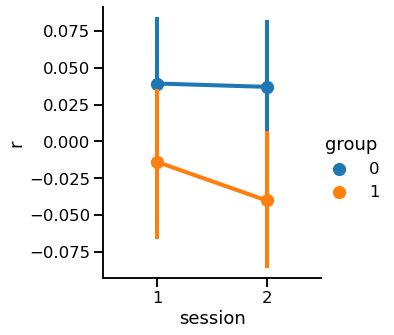

In [54]:
sns.set_context('talk')
sns.catplot(data=r.reset_index(), x='session', hue='group', y='r',kind='point',errorbar = 'se')
#plt.title(f'voxels: {n_voxels}')

pingouin.mixed_anova(data=r.reset_index(),dv='r', between='group', within='session', subject='subject')


## number of voxels in mask used for decoding


In [35]:
# look at number of voxels:
key = 'decoded_pdfs.volume'
n_voxels =='select'
mask = 'mpfc'
retroicor = False
value = True

In [29]:
# number - NPC_R version

mask = 'NPC_R'
retroicor = True
value = False

In [36]:
r2s = []
for (subject, session) in product(subjects, sessions):
    subject = f'{subject:02d}'

    if n_voxels =='select':
        key = 'decoded_pdfs.volume.cv_voxel_selection.denoise'
        fn = f'sub-{subject}_ses-{session}_mask-{mask}_space-T1w_r2s.tsv'
    else: 
        key = f'{key}.denoise.{n_voxels}voxels' # bad coding, order of vselect-method & denoise different 
        fn = f'sub-{subject}_ses-{session}_mask-{mask}_nvoxels-{n_voxels}_space-T1w_r2s.tsv'
    if value:
        key += '.value'
    if retroicor:
        key += '.retroicor'

    r2 = op.join(bids_folder, 'derivatives', key, f'sub-{subject}', 'func', fn)
    try:
        r2 = pd.read_csv(r2, sep='\t', index_col=[0])
        r2s.append(r2)
    except: 
        print(f'sub-{subject}_ses-{session} does not work')

  9%|▉         | 9/100 [00:00<00:03, 23.16it/s]

sub-03_ses-1 does not work


 16%|█▌        | 16/100 [00:00<00:03, 26.80it/s]

sub-10_ses-1 does not work


 34%|███▍      | 34/100 [00:01<00:02, 24.62it/s]

...

 50%|█████     | 50/100 [00:02<00:01, 25.93it/s]

sub-32_ses-1 does not work
sub-35_ses-1 does not work
sub-35_ses-2 does not work


 89%|████████▉ | 89/100 [00:03<00:00, 24.61it/s]

sub-52_ses-1 does not work


100%|██████████| 100/100 [00:04<00:00, 23.39it/s]


In [37]:
r2s = pd.concat(r2s).set_index(['session','test_run1','test_run2'], append=True)
r2s.head()

0         1         2         3  \
subject session test_run1 test_run2                                           
1       1       1         2         -0.143704 -0.060384 -0.677737 -0.349450   
                          3         -0.047721 -0.003862  0.163428  0.031809   
                          4          0.032246 -0.007686 -0.579976 -0.125171   
                          5         -0.059832 -0.038425 -0.051362 -0.067794   
                          6         -0.018100 -0.299275  0.086374 -0.073756   

                                            4         5         6         7  \
subject session test_run1 test_run2                                           
1       1       1         2          0.006946 -0.123934 -0.503007 -0.107363   
                          3         -0.104346 -0.005856  0.161124  0.011020   
                          4         -0.066267 -0.140024 -0.040079 -0.309687   
                          5          0.003529 -0.066200  0.135899 -2.555637   
                          6         -0.097358 -0.067345 -0.176487  0.019362   

                                            8         9  ...  3245  3246  \
subject session test_run1 test_run2                      ...               
1       1       1         2         -0.018983 -0.003816  ...   NaN   NaN   
                          3          0.010908 -0.433382  ...   NaN   NaN   
                          4         -0.333945 -0.144423  ...   NaN   NaN   
                          5         -0.092062 -0.026384  ...   NaN   NaN   
                          6         -0.013372 -0.010586  ...   NaN   NaN   

                                     3247  3248  3249  3250  3251  3252  3253  \
subject session test_run1 test_run2                                             
1       1       1         2           NaN   NaN   NaN   NaN   NaN   NaN   NaN   
                          3           NaN   NaN   NaN   NaN   NaN   NaN   NaN   
                          4           NaN   NaN   NaN   NaN   NaN   NaN   NaN   
                          5           NaN   NaN   NaN   NaN   NaN   NaN   NaN   
                          6           NaN   NaN   NaN   NaN   NaN   NaN   NaN   

                                     3254  
subject session test_run1 test_run2        
1       1       1         2           NaN  
                          3           NaN  
                          4           NaN  
                          5           NaN  
                          6           NaN  

[5 rows x 3255 columns]

In [42]:
np.isfinite(r2s).sum(axis=1)

subject  session  test_run1  test_run2
1        1        1          2            2692
                             3            2692
                             4            2692
                             5            2692
                             6            2692
                                          ... 
61       2        6          1            2986
                             2            2986
                             3            2986
                             4            2986
                             5            2986
Length: 2790, dtype: int64

In [39]:
(r2s > 0.0).sum(axis=1).groupby(['subject','session']).mean()

subject  session
1        1          548.433333
         2          604.433333
2        1          603.133333
         2          616.733333
3        2          524.033333
                       ...    
58       2          550.466667
59       1          660.733333
         2          706.400000
61       1          586.233333
         2          627.900000
Length: 93, dtype: float64

In [34]:
df.head()

session        rt         n1         n2  prob1  prob2  \
subject run trial_nr                                                          
1       1   1               1  0.476974   9.523860  10.189897   0.55    1.0   
            2               1  0.505059   6.841144   7.347297   0.55    1.0   
            3               1  0.609260   9.523860   7.347297   0.55    1.0   
            4               1  0.522144  19.781348  26.194217   0.55    1.0   
            5               1  0.608297  10.971426  10.189897   0.55    1.0   

                      choice  risky_first  chose_risky    n_risky     n_safe  \
subject run trial_nr                                                           
1       1   1           True         True        False   9.523860  10.189897   
            2           True         True        False   6.841144   7.347297   
            3          False         True         True   9.523860   7.347297   
            4           True         True        False  19.781348  26.194217   
            5          False         True         True  10.971426  10.189897   

                          frac  log(risky/safe)   log(n1) bin(risky/safe)  \
subject run trial_nr                                                        
1       1   1         0.934637        -0.067597  2.253800             44%   
            2         0.931110        -0.071377  1.922955             44%   
            3         1.296240         0.259468  2.253800             68%   
            4         0.755180        -0.280799  2.984739             20%   
            5         1.076696         0.073898  2.395294             56%   

                        p1   p2  group  
subject run trial_nr                    
1       1   1         0.55  1.0      0  
            2         0.55  1.0      0  
            3         0.55  1.0      0  
            4         0.55  1.0      0  
            5         0.55  1.0      0